# COMPAS Fairness Evaluation


In [1]:
!pip install shap --quiet

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score



All imports successful.


In [2]:
from google.colab import files
uploaded = files.upload()  # Uploading compas-scores-two-years.csv

import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Loaded {len(df_raw)} rows')

Saving compas-scores-two-years.csv to compas-scores-two-years.csv
Loaded 7214 rows


## 3. Preprocessing (ProPublica filters)

In [11]:
def load_and_preprocess(df):
    df = df[df['days_b_screening_arrest'] <= 30]
    df = df[df['days_b_screening_arrest'] >= -30]
    df = df[df['is_recid'] != -1]
    df = df[df['c_charge_degree'] != 'O']
    df = df[df['score_text'] != 'N/A']
    return df.reset_index(drop=True)

df = load_and_preprocess(df_raw)
print(f'After filtering: {len(df)} rows')
print(f'Recidivism rate: {df["two_year_recid"].mean():.1%}')
print(f'Race breakdown:\n{df["race"].value_counts()}')

After filtering: 6172 rows
Recidivism rate: 45.5%
Race breakdown:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


## 4. Feature Preparation

In [12]:
def prepare_features(df, include_proxy=True):
    features = {}
    features['age'] = df['age'].values
    features['sex_male'] = (df['sex'] == 'Male').astype(int).values
    features['charge_degree_felony'] = (df['c_charge_degree'] == 'F').astype(int).values

    if include_proxy:
        features['priors_count']    = df['priors_count'].values
        features['juv_fel_count']   = df['juv_fel_count'].values
        features['juv_misd_count']  = df['juv_misd_count'].values
        features['juv_other_count'] = df['juv_other_count'].values

    age_dummies = pd.get_dummies(df['age_cat'], prefix='age_cat')
    for col in age_dummies.columns:
        features[col] = age_dummies[col].values

    X = pd.DataFrame(features)
    y = df['two_year_recid'].values
    return X, y, list(X.columns)

X, y, feature_names = prepare_features(df, include_proxy=True)
print(f'Feature matrix: {X.shape}')
print(f'Features: {feature_names}')

Feature matrix: (6172, 10)
Features: ['age', 'sex_male', 'charge_degree_felony', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'age_cat_25 - 45', 'age_cat_Greater than 45', 'age_cat_Less than 25']


## 5. Train/Test Split

In [13]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

race_test = df.loc[idx_test, 'race'].values

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 4937 | Test: 1235


## 6. Train Models

In [14]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=10,
    min_samples_leaf=4, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr_model = LogisticRegression(
    penalty='l2', C=1.0, solver='liblinear',
    max_iter=1000, class_weight='balanced', random_state=42
)
lr_model.fit(X_train_sc, y_train)
lr_pred  = lr_model.predict(X_test_sc)
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]

print('Performance')
print(f'Random Forest  — Accuracy: {accuracy_score(y_test, rf_pred):.4f} | AUC: {roc_auc_score(y_test, rf_proba):.4f}')
print(f'Logistic Reg.  — Accuracy: {accuracy_score(y_test, lr_pred):.4f} | AUC: {roc_auc_score(y_test, lr_proba):.4f}')

=== Baseline Performance ===
Random Forest  — Accuracy: 0.6850 | AUC: 0.7265
Logistic Reg.  — Accuracy: 0.6858 | AUC: 0.7312


## 7. SHAP Analysis
### 7a. Random Forest  Global Feature Importance

SHAP values computed for Random Forest.


<Figure size 640x480 with 0 Axes>

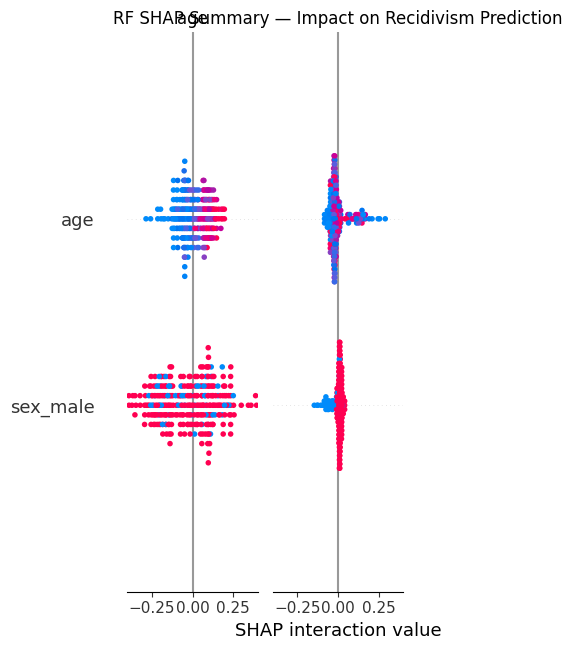

Saved: shap_rf_beeswarm.png


<Figure size 1000x600 with 0 Axes>

In [15]:
# Using a sample
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_sample  = X_test_df.sample(300, random_state=42)

rf_explainer   = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_sample)

if isinstance(rf_shap_values, list):
    rf_sv = rf_shap_values[1]
else:
    rf_sv = rf_shap_values

print('SHAP values computed for Random Forest.')

# --- Beeswarm Plot ---
plt.figure()
shap.summary_plot(rf_sv, X_sample, feature_names=feature_names, show=False)
plt.title('RF SHAP Summary — Impact on Recidivism Prediction')
plt.tight_layout()
plt.savefig('shap_rf_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
plt.gcf().set_size_inches(10, 6)
print('Saved: shap_rf_beeswarm.png')

## SHAP Global Feature Importance ,  What is driving the model's predictions?


SHAP (SHapley Additive exPlanations) : a technique that breaks down each individual
prediction and assigns a contribution score to every feature. Rather than just knowing
SHAP tells us why the model predicts the way it does .

In this beeswarm plot, each dot represents one defendant in the test set. The x-axis
shows the SHAP value , how much that feature pushed the prediction toward high risk
(right) or low risk (left). The color represents the feature value: pink means high,
blue means low.

**What the results show:**
The two dominant features are age and priors_count. For age, we can see that
younger defendants (pink dots pushed right) are consistently flagged as higher risk,
while older defendants (blue dots pushed left) are pushed toward lower risk predictions.


priors_count behaves as expected , defendants with many prior charges (pink) are
pushed strongly toward high risk predictions. prior criminal history
is not race-neutral in a system with documented patterns of over-policing in Black
communities.

**Why this matters for our project:**
Our paper raises the concern that features like prior charges can act as proxy variables
for race , encoding racial bias indirectly even when race is not explicitly included as
an input. This plot  confirms that
priors_count is one of the most influential features in the model, setting up our proxy
variable analysis .

### 7b. Random Forest , SHAP by Race (Proxy Variable Check)

SHAP array shape: (1235, 10)


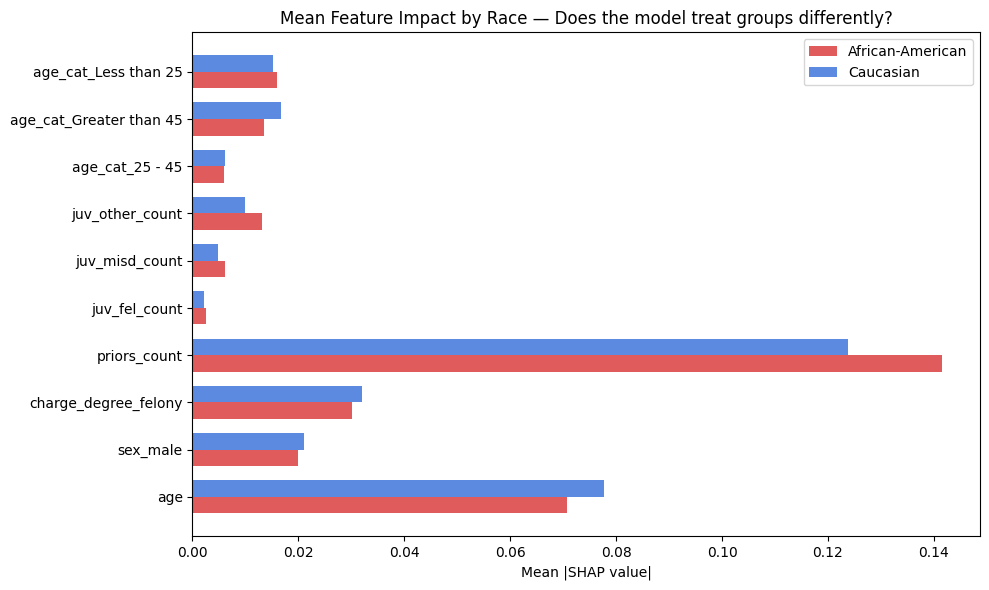

Saved: shap_rf_by_race.png


In [27]:

X_test_np = np.array(X_test)
race_test_np = np.array(race_test)

rf_explainer_full = shap.TreeExplainer(rf_model)
rf_sv_full = rf_explainer_full.shap_values(X_test_np)

# Handle all possible SHAP output shapes
if isinstance(rf_sv_full, list):
    rf_sv_full = rf_sv_full[1]          # list of 2 arrays → take class 1
elif rf_sv_full.ndim == 3:
    rf_sv_full = rf_sv_full[:, :, 1]    # 3D array (n, features, classes) → take class 1

print(f'SHAP array shape: {rf_sv_full.shape}')

# Mean absolute SHAP per feature per race
shap_by_race = {}
for r in ['African-American', 'Caucasian']:
    mask = (race_test_np == r)
    if mask.sum() == 0:
        continue
    shap_by_race[r] = np.abs(rf_sv_full[mask]).mean(axis=0)

shap_race_df = pd.DataFrame(shap_by_race, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(feature_names))
w = 0.35
ax.barh(x - w/2, shap_race_df.get('African-American', [0]*len(feature_names)),
        w, label='African-American', color='#E05C5C')
ax.barh(x + w/2, shap_race_df.get('Caucasian', [0]*len(feature_names)),
        w, label='Caucasian', color='#5C8AE0')
ax.set_yticks(x)
ax.set_yticklabels(feature_names)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Mean Feature Impact by Race — Does the model treat groups differently?')
ax.legend()
plt.tight_layout()
plt.savefig('shap_rf_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_rf_by_race.png')

## SHAP by Race

This plot directly investigates proxy variable discrimination. Using the same SHAP
framework, It computes the mean absolute SHAP value for each feature separately for
African-American and Caucasian defendants. If the model is treating racial groups
equally, we would expect the bars to be roughly the same length for both groups across
all features.

**What the results show:**
 The mean SHAP contribution of
priors_count is  larger for African-American defendants This means the model is leaning on prior criminal history
more heavily when making predictions about Black defendants than when making predictions
about white defendants.

`age` is the second most important feature and shows a smaller gap between groups,
suggesting it behaves more consistently across races. The juvenile history features
(juv_fel_count, juv_misd_count, juv_other_count) have relatively small SHAP values for
both groups.

 Race is not included as a
feature in this model , yet the model is effectively using priors_count as a replacement
for race, weighting it more heavily for Black defendants.

### 7c. Logistic Regression SHAP

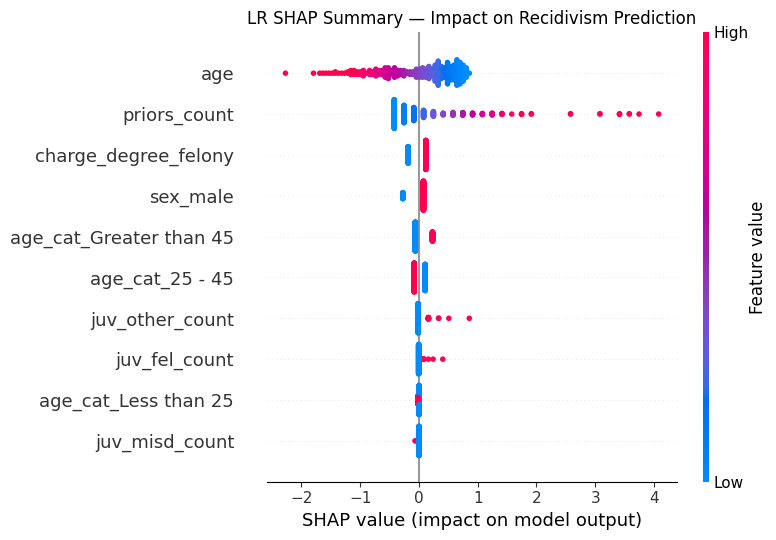

Saved: shap_lr_beeswarm.png


In [20]:
X_sample_sc = scaler.transform(X_sample)

lr_explainer   = shap.LinearExplainer(lr_model, X_train_sc)
lr_shap_values = lr_explainer.shap_values(X_sample_sc)

plt.figure()
shap.summary_plot(lr_shap_values, X_sample, feature_names=feature_names, show=False)
plt.title('LR SHAP Summary — Impact on Recidivism Prediction')
plt.tight_layout()
plt.savefig('shap_lr_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_lr_beeswarm.png')


The logistic regression model is even more concentrated on two features than the Random
Forest. `age` is the dominant predictor, young defendants (blue, low
age value) are pushed strongly to the right toward high risk. `priors_count` is the
second strongest feature, with high prior counts (pink) pushing predictions toward high
risk.

all other features : charge degree, sex, juvenile history, age categories
have relatively small SHAP values in the logistic regression compared to these top two.

the model could be to simple for this problem

This connects directly to Dressel & Farid (2018) cited in our literature review, who
found that simple models with just a handful of features can match COMPAS accuracy. Our
logistic regression achieves 68.6% accuracy using essentially two features — age and
priors
the question here is  whether a complex  tool like
COMPAS is  necessary, and whether it being more complex introduces more bias without
improving prediction.

## 8. Fairness Metrics by Race

In [21]:
def fairness_metrics(y_true, y_pred, race_labels):

    races = ['African-American', 'Caucasian', 'Hispanic', 'Other']
    rows = []
    for r in races:
        mask = (race_labels == r)
        if mask.sum() == 0:
            continue
        yt = y_true[mask]
        yp = y_pred[mask]
        tn = ((yt==0)&(yp==0)).sum()
        fp = ((yt==0)&(yp==1)).sum()
        fn = ((yt==1)&(yp==0)).sum()
        tp = ((yt==1)&(yp==1)).sum()
        fpr = fp/(fp+tn) if (fp+tn)>0 else 0
        fnr = fn/(fn+tp) if (fn+tp)>0 else 0
        tpr = tp/(tp+fn) if (tp+fn)>0 else 0
        ppv = tp/(tp+fp) if (tp+fp)>0 else 0
        sel = yp.mean()
        rows.append({'Race': r, 'N': mask.sum(),
                     'FPR': fpr, 'FNR': fnr, 'TPR': tpr,
                     'PPV': ppv, 'Selection_Rate': sel})
    return pd.DataFrame(rows).set_index('Race')

print(' Random Forest Fairness ')
rf_fairness = fairness_metrics(y_test, rf_pred, race_test)
display(rf_fairness.round(3))

print('\n Logistic Regression Fairness ')
lr_fairness = fairness_metrics(y_test, lr_pred, race_test)
display(lr_fairness.round(3))

# Key disparity numbers
print('\n Key Disparities (African-American vs Caucasian) ')
for model_name, fm in [('RF', rf_fairness), ('LR', lr_fairness)]:
    if 'African-American' in fm.index and 'Caucasian' in fm.index:
        aa  = fm.loc['African-American']
        cau = fm.loc['Caucasian']
        print(f'{model_name} — FPR gap: {aa["FPR"] - cau["FPR"]:+.3f} | FNR gap: {aa["FNR"] - cau["FNR"]:+.3f} | TPR gap: {aa["TPR"] - cau["TPR"]:+.3f}')

=== Random Forest Fairness ===


,N,FPR,FNR,TPR,PPV,Selection_Rate
Race,,,,,,
African-American,641,0.375,0.228,0.772,0.695,0.583
Caucasian,427,0.229,0.540,0.460,0.548,0.316
Hispanic,94,0.224,0.467,0.533,0.686,0.372
Other,65,0.149,0.556,0.444,0.533,0.231



=== Logistic Regression Fairness ===


,N,FPR,FNR,TPR,PPV,Selection_Rate
Race,,,,,,
African-American,641,0.385,0.208,0.792,0.695,0.599
Caucasian,427,0.222,0.547,0.453,0.553,0.309
Hispanic,94,0.265,0.489,0.511,0.639,0.383
Other,65,0.170,0.556,0.444,0.500,0.246



=== Key Disparities (African-American vs Caucasian) ===
RF — FPR gap: +0.146 | FNR gap: -0.312 | TPR gap: +0.312
LR — FPR gap: +0.163 | FNR gap: -0.339 | TPR gap: +0.339


### 8a. Visualize Fairness Gaps

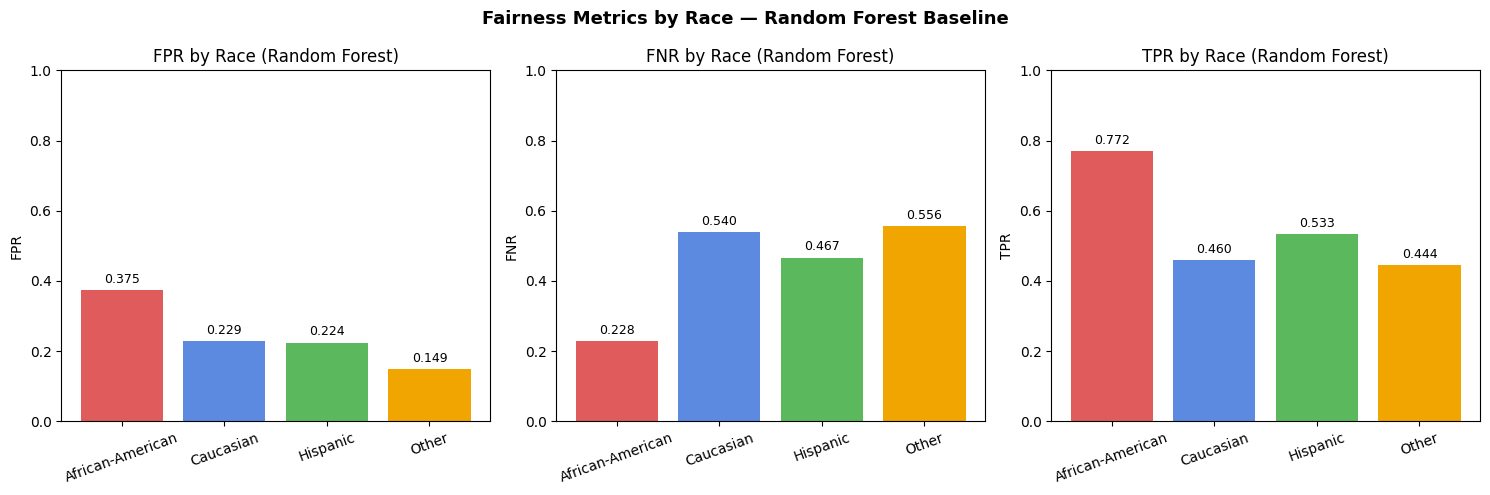

Saved: fairness_by_race_rf.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = ['FPR', 'FNR', 'TPR']
colors = ['#E05C5C', '#5C8AE0', '#5CB85C', '#F0A500']

for ax, metric in zip(axes, metrics_to_plot):
    rf_vals = rf_fairness[metric].values
    races   = rf_fairness.index.tolist()
    bars = ax.bar(races, rf_vals, color=colors[:len(races)])
    ax.set_title(f'{metric} by Race (Random Forest)')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, rf_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Fairness Metrics by Race — Random Forest Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_by_race_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fairness_by_race_rf.png')

## Fairness Audit — FPR, FNR, and TPR by Race



- **FPR (False Positive Rate):** Of defendants who did NOT reoffend, what proportion
  were incorrectly flagged as high risk? A high FPR means the model is generating
  false alarms — defendants are being penalized (higher bail, longer sentences, denied
  parole) for crimes they did not go on to commit.

- **FNR (False Negative Rate):** Of defendants who DID reoffend, what proportion were
  incorrectly labeled low risk? A high FNR means the model is giving a pass to people
  who go on to reoffend.

- **TPR (True Positive Rate / Recall):** Of defendants who reoffended, what proportion
  were correctly identified as high risk?



- **FPR gap: +0.146 (RF) / +0.163 (LR)** — African-American defendants who did not
  reoffend were flagged as high risk at a rate 14-16 percentage points higher than
  Caucasian defendants.
- **FNR gap: -0.312 (RF)** — The flip side is that Caucasian defendants who did
  reoffend were missed at a much higher rate. White defendants who went on to commit
  crimes were labeled low risk 54% of the time, compared to only 23% for Black
  defendants.

this repeats pro publicas findings

## 9. Proxy Variable Test


In [23]:
# --- No-proxy feature set ---
X_np, y_np, fn_np = prepare_features(df, include_proxy=False)

X_train_np, X_test_np, y_train_np, y_test_np, idx_train_np, idx_test_np = train_test_split(
    X_np, y_np, df.index, test_size=0.2, random_state=42, stratify=y_np
)
race_test_np = df.loc[idx_test_np, 'race'].values

rf_np = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=10,
    min_samples_leaf=4, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_np.fit(X_train_np, y_train_np)
rf_np_pred  = rf_np.predict(X_test_np)
rf_np_proba = rf_np.predict_proba(X_test_np)[:, 1]

print(' Proxy Variable Test Results ')
print(f'With proxies    — Accuracy: {accuracy_score(y_test, rf_pred):.4f} | AUC: {roc_auc_score(y_test, rf_proba):.4f}')
print(f'Without proxies — Accuracy: {accuracy_score(y_test_np, rf_np_pred):.4f} | AUC: {roc_auc_score(y_test_np, rf_np_proba):.4f}')

print('\nFairness  With Proxies:')
fm_with = fairness_metrics(y_test, rf_pred, race_test)
display(fm_with[['FPR','FNR','TPR']].round(3))

print('\nFairness  Without Proxies:')
fm_without = fairness_metrics(y_test_np, rf_np_pred, race_test_np)
display(fm_without[['FPR','FNR','TPR']].round(3))

# Gap comparison
print('\nFPR Gap (AA - Caucasian):')
for label, fm in [('With proxies', fm_with), ('Without proxies', fm_without)]:
    if 'African-American' in fm.index and 'Caucasian' in fm.index:
        gap = fm.loc['African-American','FPR'] - fm.loc['Caucasian','FPR']
        print(f'  {label}: {gap:+.3f}')

=== Proxy Variable Test Results ===
With proxies    — Accuracy: 0.6850 | AUC: 0.7265
Without proxies — Accuracy: 0.5628 | AUC: 0.5981

Fairness — With Proxies:


,FPR,FNR,TPR
Race,,,
African-American,0.375,0.228,0.772
Caucasian,0.229,0.540,0.460
Hispanic,0.224,0.467,0.533
Other,0.149,0.556,0.444



Fairness — Without Proxies:


,FPR,FNR,TPR
Race,,,
African-American,0.490,0.380,0.620
Caucasian,0.387,0.528,0.472
Hispanic,0.408,0.533,0.467
Other,0.447,0.389,0.611



FPR Gap (AA - Caucasian):
  With proxies: +0.146
  Without proxies: +0.103


## Proxy Variable Test — What happens when we remove biased features?



Removing prior counts and juvenile history:
- Reduces accuracy by **12.2 percentage points** ,  a significant cost
- Reduces the AUC from 0.727 to 0.598 — the model becomes much weaker
- **Reduces the FPR gap from 0.146 to 0.103** — a meaningful fairness improvement of
  about 30%

the FPR gap does not disappear completely even without these features. This
tells us that age and charge degree alone still encode some racial disparity, likely
because the criminal justice system's patterns of over-charging and differential
sentencing affect these variables too.

this shows you can have a
more accurate model or a fairer one, but not fully both. This trade-off is part of what we talked about in our paper .

## 10. Threshold Adjustment (Fairness Intervention)
Instead of threshold=0.5 for everyone, find a per-group threshold that equalizes FPR.

In [24]:
def find_threshold_for_fpr(y_true, y_proba, target_fpr):
    from sklearn.metrics import roc_curve
    fpr_arr, tpr_arr, thresholds = roc_curve(y_true, y_proba)
    idx = np.argmin(np.abs(fpr_arr - target_fpr))
    return thresholds[idx]

def apply_group_thresholds(y_proba, race_labels, thresholds_dict):
    """Apply different thresholds per racial group."""
    y_pred_adj = np.zeros(len(y_proba), dtype=int)
    for r, thresh in thresholds_dict.items():
        mask = (race_labels == r)
        y_pred_adj[mask] = (y_proba[mask] >= thresh).astype(int)
    return y_pred_adj

# match Caucasian FPR for all groups
target_fpr = rf_fairness.loc['Caucasian', 'FPR'] if 'Caucasian' in rf_fairness.index else 0.3
print(f'Target FPR (Caucasian baseline): {target_fpr:.3f}')

group_thresholds = {}
for r in ['African-American', 'Caucasian', 'Hispanic', 'Other']:
    mask = (race_test == r)
    if mask.sum() < 10:
        continue
    t = find_threshold_for_fpr(y_test[mask], rf_proba[mask], target_fpr)
    group_thresholds[r] = t
    print(f'  {r:20s}: threshold = {t:.3f}')

# Apply adjusted thresholds
rf_adj_pred = apply_group_thresholds(rf_proba, race_test, group_thresholds)

print('\n=== After Threshold Adjustment ===')
print(f'Accuracy: {accuracy_score(y_test, rf_adj_pred):.4f}  (was {accuracy_score(y_test, rf_pred):.4f})')
fm_adj = fairness_metrics(y_test, rf_adj_pred, race_test)
display(fm_adj[['FPR','FNR','TPR']].round(3))

print('\nFPR Gap (AA - Caucasian):')
for label, fm in [('Baseline', rf_fairness), ('After threshold adj.', fm_adj)]:
    if 'African-American' in fm.index and 'Caucasian' in fm.index:
        gap = fm.loc['African-American','FPR'] - fm.loc['Caucasian','FPR']
        print(f'  {label}: {gap:+.3f}')

Target FPR (Caucasian baseline): 0.229
  African-American    : threshold = 0.613
  Caucasian           : threshold = 0.501
  Hispanic            : threshold = 0.495
  Other               : threshold = 0.467

=== After Threshold Adjustment ===
Accuracy: 0.6623  (was 0.6850)


,FPR,FNR,TPR
Race,,,
African-American,0.227,0.436,0.564
Caucasian,0.229,0.540,0.460
Hispanic,0.245,0.467,0.533
Other,0.213,0.500,0.500



FPR Gap (AA - Caucasian):
  Baseline: +0.146
  After threshold adj.: -0.002


## Threshold Adjustment — Can we fix fairness without retraining?

 We keep the trained Random Forest exactly as is, but
instead of applying a single classification cutoff of 0.5 for all defendants, we find
a different threshold for each racial group that equalizes the FPR across groups.

 the model outputs a probability between 0 and 1 for each defendant.
Normally, anyone above 0.5 is classified high risk. Here, the threshold for African American defendants is lowered  making the model less likely to flag them as high risk ,
until their FPR matched the Caucasian baseline.


The FPR gap is  eliminated — dropping from +0.146 to -0.002. The accuracy
cost is modest at 2.3 percentage points.

looking at the FNR: after adjustment, African-American FNR is 0.436 vs
Caucasian 0.540 — the FNR gap has narrowed from -0.312 to -0.104. This means we
improved FNR equity as a side effect, but we did not achieve full equalized odds
(which would require both FPR and FNR to be equal simultaneously).



## 11. Summary Comparison Table


In [25]:
def get_fpr_gap(fm):
    if 'African-American' in fm.index and 'Caucasian' in fm.index:
        return fm.loc['African-American','FPR'] - fm.loc['Caucasian','FPR']
    return None

results = [
    {'Model': 'Logistic Regression (baseline)',
     'Accuracy': accuracy_score(y_test, lr_pred),
     'AUC': roc_auc_score(y_test, lr_proba),
     'FPR_gap (AA-White)': get_fpr_gap(lr_fairness),
     'FNR_gap (AA-White)': lr_fairness.loc['African-American','FNR'] - lr_fairness.loc['Caucasian','FNR'] if 'African-American' in lr_fairness.index else None},

    {'Model': 'Random Forest (baseline)',
     'Accuracy': accuracy_score(y_test, rf_pred),
     'AUC': roc_auc_score(y_test, rf_proba),
     'FPR_gap (AA-White)': get_fpr_gap(rf_fairness),
     'FNR_gap (AA-White)': rf_fairness.loc['African-American','FNR'] - rf_fairness.loc['Caucasian','FNR'] if 'African-American' in rf_fairness.index else None},

    {'Model': 'RF — No Proxy Variables',
     'Accuracy': accuracy_score(y_test_np, rf_np_pred),
     'AUC': roc_auc_score(y_test_np, rf_np_proba),
     'FPR_gap (AA-White)': get_fpr_gap(fm_without),
     'FNR_gap (AA-White)': fm_without.loc['African-American','FNR'] - fm_without.loc['Caucasian','FNR'] if 'African-American' in fm_without.index else None},

    {'Model': 'RF — Threshold Adjusted',
     'Accuracy': accuracy_score(y_test, rf_adj_pred),
     'AUC': roc_auc_score(y_test, rf_proba),
     'FPR_gap (AA-White)': get_fpr_gap(fm_adj),
     'FNR_gap (AA-White)': fm_adj.loc['African-American','FNR'] - fm_adj.loc['Caucasian','FNR'] if 'African-American' in fm_adj.index else None},
]

summary_df = pd.DataFrame(results).set_index('Model')
display(summary_df.round(4))

,Accuracy,AUC,FPR_gap (AA-White),FNR_gap (AA-White)
Model,,,,
Logistic Regression (baseline),0.6858,0.7312,0.1631,-0.3389
Random Forest (baseline),0.6850,0.7265,0.1457,-0.3119
RF — No Proxy Variables,0.5628,0.5981,0.1029,-0.1481
RF — Threshold Adjusted,0.6623,0.7265,-0.0023,-0.1042
